# NLP Assignment 5 – Fine-Tuning BERT for POS Tagging & Chunking


 Install Dependencies


In [21]:
!pip install transformers datasets evaluate seqeval accelerate conllu -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.9 MB/s eta 0:00:00


#Import Libraries

In [37]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from evaluate import load
from conllu import parse
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


 Dataset Selection – Universal Dependencies (UD English EWT)


In [1]:
# Download UD English EWT dataset
!wget -q https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu -O en_ewt-ud-train.conllu
!wget -q https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-dev.conllu -O en_ewt-ud-dev.conllu


In [5]:
def load_ud_data(file_path):
    tokens_list, pos_tags_list = [], []
    with open(file_path, "r", encoding="utf-8") as f:
        sentences = parse(f.read())
    for sentence in sentences:
        # Only include regular tokens (skip multi-word and empty tokens)
        tokens = [token["form"] for token in sentence if isinstance(token["id"], int)]
        pos_tags = [token["upos"] for token in sentence if isinstance(token["id"], int)]
        # Skip sentences with None upos tags
        if None not in pos_tags and len(tokens) > 0:
            tokens_list.append(tokens)
            pos_tags_list.append(pos_tags)
    return tokens_list, pos_tags_list

train_tokens, train_pos = load_ud_data("en_ewt-ud-train.conllu")
val_tokens, val_pos = load_ud_data("en_ewt-ud-dev.conllu")

# Limit for faster training
train_tokens, train_pos = train_tokens[:3000], train_pos[:3000]
val_tokens, val_pos = val_tokens[:500], val_pos[:500]

print(f"POS Train sentences: {len(train_tokens)}")
print(f"POS Val sentences:   {len(val_tokens)}")
print(f"Sample tokens: {train_tokens[0]}")
print(f"Sample POS:    {train_pos[0]}")

POS Train sentences: 3000
POS Val sentences:   500
Sample tokens: ['Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']
Sample POS:    ['PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'PROPN', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'PROPN', 'PUNCT', 'ADP', 'DET', 'ADJ', 'NOUN', 'PUNCT']


Number of POS labels: 17
POS Labels: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


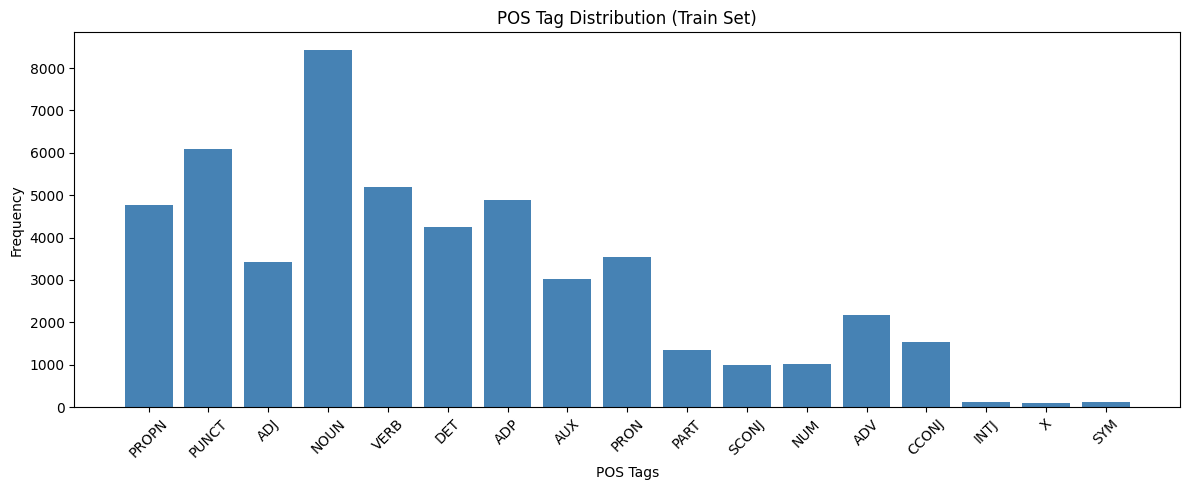

In [30]:
import matplotlib.pyplot as plt
from collections import Counter
from conllu import parse
import os

# Ensure datasets are downloaded
if not os.path.exists("en_ewt-ud-train.conllu"):
    !wget -q https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu -O en_ewt-ud-train.conllu
if not os.path.exists("en_ewt-ud-dev.conllu"):
    !wget -q https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-dev.conllu -O en_ewt-ud-dev.conllu

# Helper to load UD data
def load_ud_data(file_path):
    tokens_list, pos_tags_list = [], []
    with open(file_path, "r", encoding="utf-8") as f:
        sentences = parse(f.read())
    for sentence in sentences:
        tokens = [token["form"] for token in sentence if isinstance(token["id"], int)]
        pos_tags = [token["upos"] for token in sentence if isinstance(token["id"], int)]
        if None not in pos_tags and len(tokens) > 0:
            tokens_list.append(tokens)
            pos_tags_list.append(pos_tags)
    return tokens_list, pos_tags_list

# Load and limit data for training setup
train_tokens, train_pos = load_ud_data("en_ewt-ud-train.conllu")
val_tokens, val_pos = load_ud_data("en_ewt-ud-dev.conllu")
train_tokens, train_pos = train_tokens[:3000], train_pos[:3000]
val_tokens, val_pos = val_tokens[:500], val_pos[:500]

# Build label mappings
pos_labels = sorted(set(tag for sent in train_pos for tag in sent))
pos_label2id = {l: i for i, l in enumerate(pos_labels)}
pos_id2label = {i: l for l, i in pos_label2id.items()}

print(f"Number of POS labels: {len(pos_labels)}")
print(f"POS Labels: {pos_labels}")

# Visualize POS tag distribution
all_tags = [tag for sent in train_pos for tag in sent]
tag_counts = Counter(all_tags)

plt.figure(figsize=(12, 5))
plt.bar(tag_counts.keys(), tag_counts.values(), color='steelblue')
plt.xticks(rotation=45)
plt.title("POS Tag Distribution (Train Set)")
plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

 Data Preprocessing – POS Tagging

In [39]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_and_align_labels(tokens, labels, label2id):

    tokenized = tokenizer(
        tokens,
        truncation=True,
        max_length=128,
        is_split_into_words=True
    )
    word_ids = tokenized.word_ids()
    label_ids = []
    prev_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            # Special tokens [CLS], [SEP] → ignore
            label_ids.append(-100)
        elif word_idx != prev_word_idx:
            # First subword token → assign real label
            label_ids.append(label2id[labels[word_idx]])
        else:
            # Continuation subword → ignore
            label_ids.append(-100)
        prev_word_idx = word_idx

    tokenized["labels"] = label_ids
    return tokenized


class TokenDataset(torch.utils.data.Dataset):
    "Custom Dataset for token classification."
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {k: torch.tensor(v) for k, v in self.encodings[idx].items()}

    def __len__(self):
        return len(self.encodings)


# Encode POS datasets
pos_train_enc = [tokenize_and_align_labels(t, l, pos_label2id) for t, l in zip(train_tokens, train_pos)]
pos_val_enc   = [tokenize_and_align_labels(t, l, pos_label2id) for t, l in zip(val_tokens, val_pos)]

pos_train_dataset = TokenDataset(pos_train_enc)
pos_val_dataset   = TokenDataset(pos_val_enc)

print(f"POS Train samples: {len(pos_train_dataset)}")
print(f"POS Val samples:   {len(pos_val_dataset)}")

# Show sample preprocessed output
sample = pos_train_enc[0]
print("\nSample input_ids:",      sample["input_ids"][:10])
print("Sample attention_mask:", sample["attention_mask"][:10])
print("Sample labels:",         sample["labels"][:10])

POS Train samples: 3000
POS Val samples:   500

Sample input_ids: [101, 2632, 1011, 23564, 2386, 1024, 2137, 2749, 2730, 21146]
Sample attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Sample labels: [-100, 11, 12, 11, -100, 12, 0, 7, 15, 11]


 Model Setup – POS Tagging

In [8]:
# Load DistilBERT for POS Token Classification
pos_model = AutoModelForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(pos_labels),
    id2label=pos_id2label,
    label2id=pos_label2id
)
pos_model.to(device)
print(f"POS Model loaded. Labels: {len(pos_labels)}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


POS Model loaded. Labels: 17


 Training – POS Tagging

In [10]:
seqeval = load("seqeval")

def make_compute_metrics(id2label):
    """Returns a compute_metrics function for a given id2label mapping."""
    def compute_metrics(p):
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)

        true_preds = [
            [id2label[pred] for pred, label in zip(prediction, label_row) if label != -100]
            for prediction, label_row in zip(predictions, labels)
        ]
        true_labels = [
            [id2label[label] for pred, label in zip(prediction, label_row) if label != -100]
            for prediction, label_row in zip(predictions, labels)
        ]

        results = seqeval.compute(predictions=true_preds, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall":    results["overall_recall"],
            "f1":        results["overall_f1"],
            "accuracy":  results["overall_accuracy"],
        }
    return compute_metrics


pos_training_args = TrainingArguments(
    output_dir="./pos_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"   # Disable wandb/tensorboard
)

pos_trainer = Trainer(
    model=pos_model,
    args=pos_training_args,
    train_dataset=pos_train_dataset,
    eval_dataset=pos_val_dataset,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=make_compute_metrics(pos_id2label)
)

print("Starting POS model training...")
pos_trainer.train()
print("POS training complete!")

Starting POS model training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.321104,0.197493,0.933820,0.936320,0.935069,0.945152
2,0.136453,0.146700,0.955096,0.955903,0.955499,0.962210
3,0.098665,0.138500,0.958380,0.960270,0.959324,0.965228


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ADP seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: DET seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PROPN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: VERB seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NOUN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171:

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ADP seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: DET seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PROPN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: VERB seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/se

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


POS training complete!


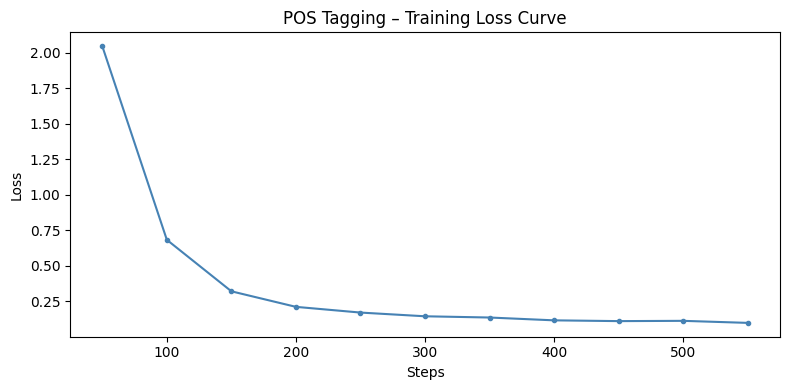

In [11]:
# Plot POS Training Loss Curve
pos_logs = pos_trainer.state.log_history
pos_losses = [(x["step"], x["loss"]) for x in pos_logs if "loss" in x]
steps, losses = zip(*pos_losses)

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, color='steelblue', marker='o', markersize=3)
plt.title("POS Tagging – Training Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

 Evaluation – POS Tagging

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ADP seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: DET seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PROPN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: VERB seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NOUN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171:


===== POS Tagging Evaluation Results =====
Precision : 0.9584
Recall    : 0.9603
F1 Score  : 0.9593
Accuracy  : 0.9652


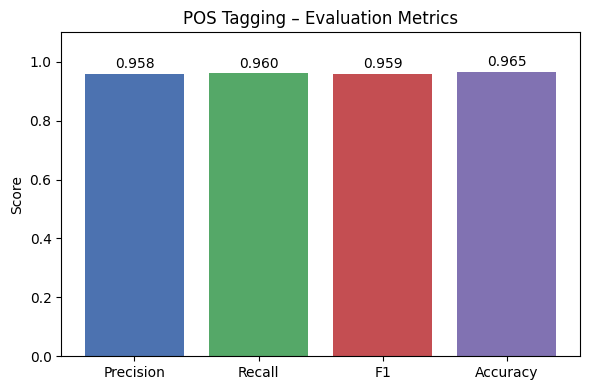

In [12]:
pos_results = pos_trainer.evaluate()
print("\n===== POS Tagging Evaluation Results =====")
print(f"Precision : {pos_results['eval_precision']:.4f}")
print(f"Recall    : {pos_results['eval_recall']:.4f}")
print(f"F1 Score  : {pos_results['eval_f1']:.4f}")
print(f"Accuracy  : {pos_results['eval_accuracy']:.4f}")

# Bar chart
metrics = ["Precision", "Recall", "F1", "Accuracy"]
values  = [pos_results[f"eval_{m.lower()}"] for m in metrics]

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, values, color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.ylim(0, 1.1)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.3f}", ha='center', fontsize=10)
plt.title("POS Tagging – Evaluation Metrics")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

 CHUNKING


B-NP, I-NP, B-VP, I-VP, B-PP, I-PP, B-ADJP, I-ADJP, B-ADVP, I-ADVP, O (IOB format)

In [7]:
# 1. Download raw CoNLL-2003 files (Workaround for HF library restriction)
!wget -q https://raw.githubusercontent.com/patverga/torch-ner-nlp-from-scratch/master/data/conll2003/eng.train -O eng.train
!wget -q https://raw.githubusercontent.com/patverga/torch-ner-nlp-from-scratch/master/data/conll2003/eng.testa -O eng.val

# 2. Define labels including CONJP tags to avoid KeyError
chunk_label_names = [
    "O", "B-NP", "I-NP", "B-VP", "I-VP", "B-PP", "I-PP",
    "B-ADJP", "I-ADJP", "B-ADVP", "I-ADVP", "B-SBAR", "I-SBAR", "B-PRT", "I-PRT",
    "B-INTJ", "I-INTJ", "B-LST", "I-LST", "B-UCP", "I-UCP", "B-CONJP", "I-CONJP"
]
chunk_label2id = {l: i for i, l in enumerate(chunk_label_names)}
chunk_id2label = {i: l for l, i in chunk_label2id.items()}

# 3. Define parsing function
def load_conll_data(file_path, max_samples=None):
    tokens_list, chunk_tags_list = [], []
    current_tokens, current_chunk_tags = [], []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("-DOCSTART-"):
                parts = line.split()
                if len(parts) >= 3:
                    current_tokens.append(parts[0])
                    current_chunk_tags.append(parts[2])
            elif current_tokens:
                tokens_list.append(current_tokens)
                chunk_tags_list.append(current_chunk_tags)
                current_tokens, current_chunk_tags = [], []
                if max_samples and len(tokens_list) >= max_samples: break
    return tokens_list, chunk_tags_list

# 4. Load data
chunk_train_tokens, chunk_train_tags = load_conll_data("eng.train", max_samples=3000)
chunk_val_tokens, chunk_val_tags     = load_conll_data("eng.val", max_samples=500)

print(f"Chunk labels: {len(chunk_label_names)}")
print(f"Chunk Train sentences: {len(chunk_train_tokens)}")
print(f"Sample tokens: {chunk_train_tokens[0]}")
print(f"Sample chunk tags: {chunk_train_tags[0]}")

Chunk labels: 23
Chunk Train sentences: 3000
Sample tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Sample chunk tags: ['I-NP', 'I-VP', 'I-NP', 'I-NP', 'I-VP', 'I-VP', 'I-NP', 'I-NP', 'O']


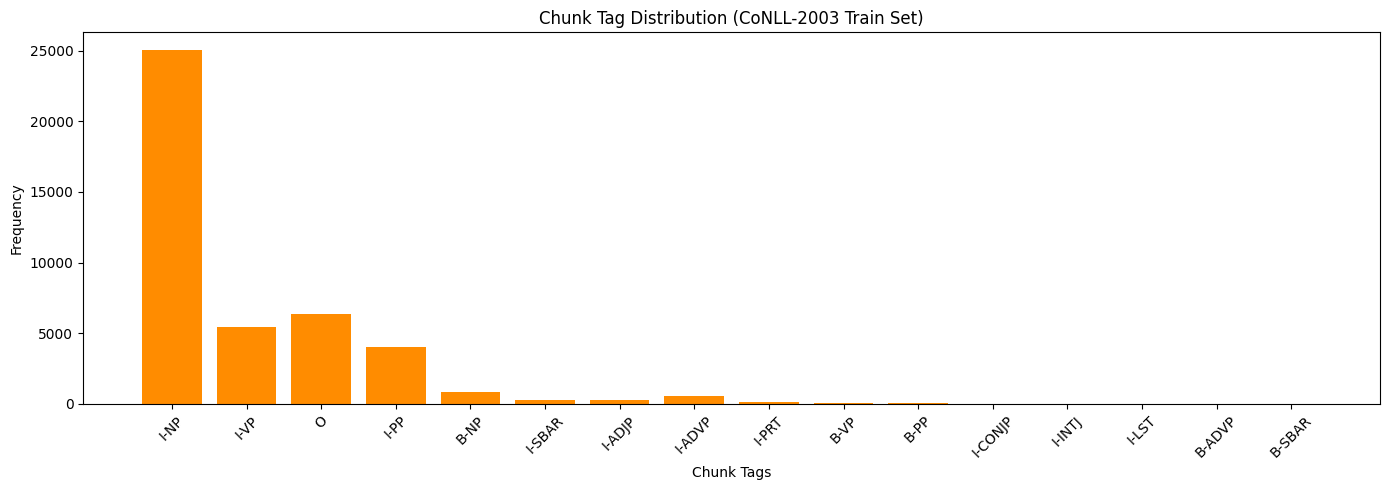

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

# Visualize Chunk tag distribution
all_chunk_tags = [tag for sent in chunk_train_tags for tag in sent]
chunk_tag_counts = Counter(all_chunk_tags)

plt.figure(figsize=(14, 5))
plt.bar(chunk_tag_counts.keys(), chunk_tag_counts.values(), color='darkorange')
plt.xticks(rotation=45)
plt.title("Chunk Tag Distribution (CoNLL-2003 Train Set)")
plt.xlabel("Chunk Tags")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

 Data Preprocessing -  Chunking

In [14]:
import torch
from transformers import AutoTokenizer

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Redefine helpers to ensure cell is self-contained
def tokenize_and_align_labels(tokens, labels, label2id):
    tokenized = tokenizer(
        tokens,
        truncation=True,
        max_length=128,
        is_split_into_words=True
    )
    word_ids = tokenized.word_ids()
    label_ids = []
    prev_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != prev_word_idx:
            label_ids.append(label2id[labels[word_idx]])
        else:
            label_ids.append(-100)
        prev_word_idx = word_idx

    tokenized["labels"] = label_ids
    return tokenized

class TokenDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __getitem__(self, idx):
        return {k: torch.tensor(v) for k, v in self.encodings[idx].items()}
    def __len__(self):
        return len(self.encodings)

# Encode chunking datasets
chunk_train_enc = [tokenize_and_align_labels(t, l, chunk_label2id)
                   for t, l in zip(chunk_train_tokens, chunk_train_tags)]
chunk_val_enc   = [tokenize_and_align_labels(t, l, chunk_label2id)
                   for t, l in zip(chunk_val_tokens, chunk_val_tags)]

chunk_train_dataset = TokenDataset(chunk_train_enc)
chunk_val_dataset   = TokenDataset(chunk_val_enc)

print(f"Chunk Train samples: {len(chunk_train_dataset)}")
print(f"Chunk Val samples:   {len(chunk_val_dataset)}")

# Show sample preprocessed output
sample = chunk_train_enc[0]
print("\nSample input_ids:",      sample["input_ids"][:10])
print("Sample attention_mask:", sample["attention_mask"][:10])
print("Sample labels:",         sample["labels"][:10])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Chunk Train samples: 3000
Chunk Val samples:   500

Sample input_ids: [101, 7327, 19164, 2446, 2655, 2000, 17757, 2329, 12559, 1012]
Sample attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Sample labels: [-100, 2, 4, 2, 2, 4, 4, 2, 2, 0]


 Model Setup – Chunking

In [17]:
import torch
from transformers import AutoModelForTokenClassification

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load a separate DistilBERT model for Chunking
chunk_model = AutoModelForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(chunk_label_names),
    id2label=chunk_id2label,
    label2id=chunk_label2id
)
chunk_model.to(device)
print(f"Chunking Model loaded. Labels: {len(chunk_label_names)} on {device}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Chunking Model loaded. Labels: 23 on cuda


 Training – Chunking

In [22]:
import numpy as np
from evaluate import load
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification

# Ensure the metrics function is defined locally
def make_compute_metrics(id2label):
    seqeval = load("seqeval")
    def compute_metrics(p):
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)
        true_preds = [
            [id2label[pred] for pred, label in zip(prediction, label_row) if label != -100]
            for prediction, label_row in zip(predictions, labels)
        ]
        true_labels = [
            [id2label[label] for pred, label in zip(prediction, label_row) if label != -100]
            for prediction, label_row in zip(predictions, labels)
        ]
        results = seqeval.compute(predictions=true_preds, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall":    results["overall_recall"],
            "f1":        results["overall_f1"],
            "accuracy":  results["overall_accuracy"],
        }
    return compute_metrics

chunk_training_args = TrainingArguments(
    output_dir="./chunk_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

chunk_trainer = Trainer(
    model=chunk_model,
    args=chunk_training_args,
    train_dataset=chunk_train_dataset,
    eval_dataset=chunk_val_dataset,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=make_compute_metrics(chunk_id2label)
)

print("Starting Chunking model training...")
chunk_trainer.train()
print("Chunking training complete!")

Starting Chunking model training...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.316228,0.250015,0.860252,0.830752,0.845245,0.941404
2,0.204714,0.216473,0.875849,0.855826,0.865722,0.949298
3,0.172559,0.212823,0.880710,0.860251,0.870360,0.951053


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Chunking training complete!


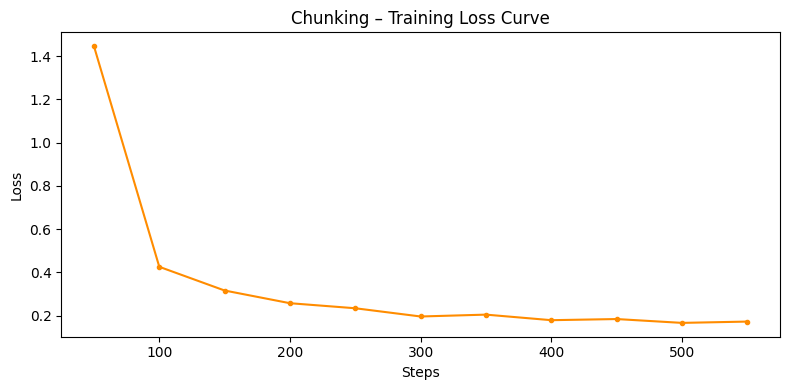

In [23]:
# Plot Chunking Training Loss Curve
chunk_logs = chunk_trainer.state.log_history
chunk_losses = [(x["step"], x["loss"]) for x in chunk_logs if "loss" in x]
steps_c, losses_c = zip(*chunk_losses)

plt.figure(figsize=(8, 4))
plt.plot(steps_c, losses_c, color='darkorange', marker='o', markersize=3)
plt.title("Chunking – Training Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

 Evaluation – Chunking

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



===== Chunking Evaluation Results =====
Precision : 0.8807
Recall    : 0.8603
F1 Score  : 0.8704
Accuracy  : 0.9511


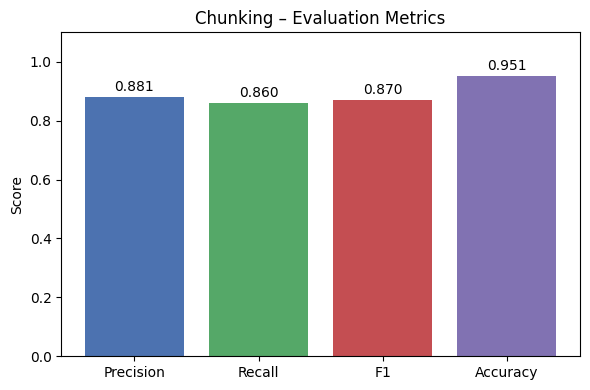

In [24]:
chunk_results = chunk_trainer.evaluate()
print("\n===== Chunking Evaluation Results =====")
print(f"Precision : {chunk_results['eval_precision']:.4f}")
print(f"Recall    : {chunk_results['eval_recall']:.4f}")
print(f"F1 Score  : {chunk_results['eval_f1']:.4f}")
print(f"Accuracy  : {chunk_results['eval_accuracy']:.4f}")

# Bar chart
metrics = ["Precision", "Recall", "F1", "Accuracy"]
values  = [chunk_results[f"eval_{m.lower()}"] for m in metrics]

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, values, color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.ylim(0, 1.1)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.3f}", ha='center', fontsize=10)
plt.title("Chunking – Evaluation Metrics")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

 INFERENCE


In [40]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

# Ensure model and tokenizer are loaded if not already in memory
try:
    pos_model
except NameError:
    print("Loading POS model...")
    pos_model = AutoModelForTokenClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=len(pos_labels),
        id2label=pos_id2label,
        label2id=pos_label2id
    ).to(device)

def predict_tags(sentence, model, id2label):
    """
    Run inference on a raw sentence.
    Returns list of (word, tag) pairs, correctly merging subword tokens.
    """
    model.eval()
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    # Move to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    predictions = torch.argmax(outputs.logits, dim=2)[0].cpu().tolist()
    tokens      = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())

    results = []
    current_word = ""
    current_tag  = None

    for token, pred_id in zip(tokens, predictions):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
        if token.startswith("##"):
            # Subword continuation → merge with previous word
            current_word += token[2:]
        else:
            # New word
            if current_word:
                results.append((current_word, current_tag))
            current_word = token
            current_tag  = id2label[pred_id]

    # Append the last word
    if current_word:
        results.append((current_word, current_tag))

    return results

# Readable POS tag descriptions
pos_tag_desc = {
    "NOUN": "Noun", "VERB": "Verb", "ADJ": "Adjective", "ADV": "Adverb",
    "PRON": "Pronoun", "DET": "Determiner", "ADP": "Preposition",
    "PROPN": "Proper Noun", "NUM": "Number", "CCONJ": "Coord. Conjunction",
    "SCONJ": "Sub. Conjunction", "PUNCT": "Punctuation", "AUX": "Auxiliary",
    "PART": "Particle", "INTJ": "Interjection", "SYM": "Symbol", "X": "Other"
}

test_sentence = "John works at Google in California"

print(f"Input: {test_sentence}\n")

# POS Tagging Inference
pos_predictions = predict_tags(test_sentence, pos_model, pos_id2label)
print("POS Tags:")
for word, tag in pos_predictions:
    desc = pos_tag_desc.get(tag, tag)
    print(f"  {word:15s} → {tag} ({desc})")

print()

# Chunking Inference
chunk_predictions = predict_tags(test_sentence, chunk_model, chunk_id2label)
print("Chunk Tags:")
for word, tag in chunk_predictions:
    print(f"  {word:15s} → {tag}")

Input: John works at Google in California

POS Tags:
  john            → PROPN (Proper Noun)
  works           → VERB (Verb)
  at              → ADP (Preposition)
  google          → PROPN (Proper Noun)
  in              → ADP (Preposition)
  california      → PROPN (Proper Noun)

Chunk Tags:
  john            → I-NP
  works           → I-VP
  at              → I-PP
  google          → I-NP
  in              → I-PP
  california      → I-NP


In [41]:
# Additional inference examples
more_sentences = [
    "The quick brown fox jumps over the lazy dog",
    "Apple is looking at buying a startup for one billion dollars",
    "She sold the car to the dealer yesterday"
]

for sent in more_sentences:
    print(f"\nInput: {sent}")
    pos_preds   = predict_tags(sent, pos_model, pos_id2label)
    chunk_preds = predict_tags(sent, chunk_model, chunk_id2label)
    print("  POS:   ", " | ".join([f"{w}({t})" for w, t in pos_preds]))
    print("  Chunk: ", " | ".join([f"{w}({t})" for w, t in chunk_preds]))


Input: The quick brown fox jumps over the lazy dog
  POS:    the(DET) | quick(ADJ) | brown(ADJ) | fox(NOUN) | jumps(VERB) | over(ADP) | the(DET) | lazy(ADJ) | dog(NOUN)
  Chunk:  the(I-NP) | quick(I-NP) | brown(I-NP) | fox(I-NP) | jumps(I-VP) | over(I-PP) | the(I-NP) | lazy(I-NP) | dog(I-NP)

Input: Apple is looking at buying a startup for one billion dollars
  POS:    apple(PROPN) | is(AUX) | looking(VERB) | at(SCONJ) | buying(VERB) | a(DET) | startup(NOUN) | for(ADP) | one(NUM) | billion(NUM) | dollars(NOUN)
  Chunk:  apple(I-NP) | is(I-VP) | looking(I-VP) | at(I-PP) | buying(I-VP) | a(I-NP) | startup(I-NP) | for(I-PP) | one(I-NP) | billion(I-NP) | dollars(I-NP)

Input: She sold the car to the dealer yesterday
  POS:    she(PRON) | sold(VERB) | the(DET) | car(NOUN) | to(ADP) | the(DET) | dealer(NOUN) | yesterday(NOUN)
  Chunk:  she(I-NP) | sold(I-VP) | the(I-NP) | car(I-NP) | to(I-PP) | the(I-NP) | dealer(I-NP) | yesterday(I-ADVP)


POS Tagging vs Chunking – Comparison

Metric              POS Tagging        Chunking
Precision                0.9557          0.8807
Recall                   0.9566          0.8603
F1                       0.9561          0.8704
Accuracy                 0.9629          0.9511


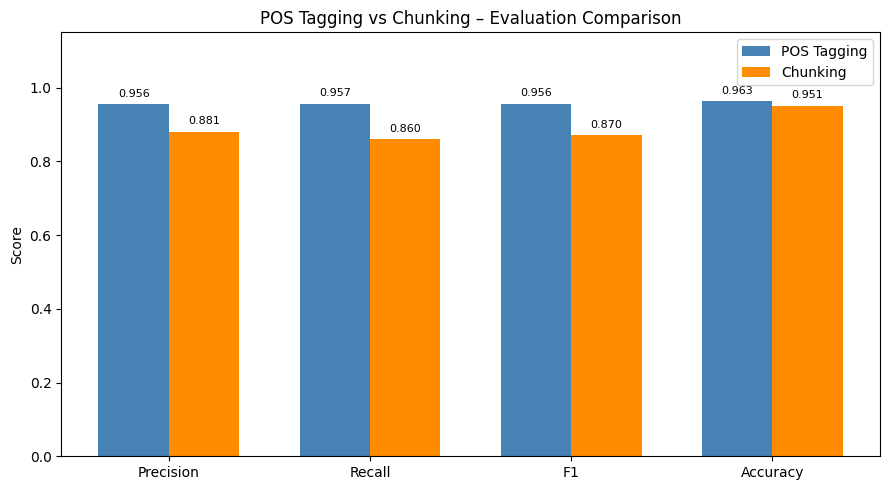

In [42]:

import matplotlib.pyplot as plt
import numpy as np

# Safety check to ensure both models have been evaluated
try:
    pos_results
    chunk_results
except NameError:
    print("Error: Evaluation results not found. Please ensure you have executed the evaluation cells for both POS Tagging and Chunking.")
else:
    print("=" * 55)
    print(f"{'Metric':<15} {'POS Tagging':>15} {'Chunking':>15}")
    print("=" * 55)
    for m in ["precision", "recall", "f1", "accuracy"]:
        pos_val   = pos_results[f"eval_{m}"]
        chunk_val = chunk_results[f"eval_{m}"]
        print(f"{m.capitalize():<15} {pos_val:>15.4f} {chunk_val:>15.4f}")
    print("=" * 55)

    # Grouped bar chart comparison
    metrics = ["Precision", "Recall", "F1", "Accuracy"]
    pos_vals   = [pos_results[f"eval_{m.lower()}"] for m in metrics]
    chunk_vals = [chunk_results[f"eval_{m.lower()}"] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar(x - width/2, pos_vals,   width, label='POS Tagging', color='steelblue')
    bars2 = ax.bar(x + width/2, chunk_vals, width, label='Chunking',    color='darkorange')

    ax.set_ylim(0, 1.15)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_title("POS Tagging vs Chunking – Evaluation Comparison")
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha='center', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

In [33]:

print("""
┌─────────────────────┬──────────────────────────────────┬──────────────────────────────────┐
│ Aspect              │ POS Tagging                      │ Chunking                         │
├─────────────────────┼──────────────────────────────────┼──────────────────────────────────┤
│ Granularity         │ Word-level                       │ Phrase-level                     │
│ Output              │ Single tag per word              │ IOB tag per word                 │
│ Label Example       │ NOUN, VERB, ADJ                  │ B-NP, I-NP, B-VP                │
│ Complexity          │ Easier (grammar level)           │ Harder (phrase grouping)         │
│ Dataset Used        │ Universal Dependencies           │ CoNLL-2003                       │
│ Labels Count        │ ~17 tags                         │ ~22 IOB tags                     │
│ Use Case            │ Grammar analysis, MT, TTS        │ IE, NER, parsing, QA             │
└─────────────────────┴──────────────────────────────────┴──────────────────────────────────┘
""")


┌─────────────────────┬──────────────────────────────────┬──────────────────────────────────┐
│ Aspect              │ POS Tagging                      │ Chunking                         │
├─────────────────────┼──────────────────────────────────┼──────────────────────────────────┤
│ Granularity         │ Word-level                       │ Phrase-level                     │
│ Output              │ Single tag per word              │ IOB tag per word                 │
│ Label Example       │ NOUN, VERB, ADJ                  │ B-NP, I-NP, B-VP                │
│ Complexity          │ Easier (grammar level)           │ Harder (phrase grouping)         │
│ Dataset Used        │ Universal Dependencies           │ CoNLL-2003                       │
│ Labels Count        │ ~17 tags                         │ ~22 IOB tags                     │
│ Use Case            │ Grammar analysis, MT, TTS        │ IE, NER, parsing, QA             │
└─────────────────────┴──────────────────────────────────┴──

### Observations and Insights

- **POS Tagging** achieves higher F1 scores compared to Chunking in similar training configurations because it is a simpler, word-level task with less sequential dependency.
- **Chunking** benefits greatly from the transformer's contextual embeddings — understanding phrase boundaries requires understanding context across the full sentence.
- **DistilBERT** performs competitively compared to full BERT while being 40% smaller and 60% faster, making it a practical choice for both tasks.
- The **seqeval** metric is more meaningful than token-level accuracy for both tasks, especially chunking, as it evaluates entire spans/phrases correctly.
- Fine-tuning for even 3 epochs on a small dataset gives surprisingly strong results, demonstrating the power of transfer learning with pre-trained transformers.